# **Modeling**

In [173]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings
from scipy.stats import loguniform, uniform
from xgboost import XGBClassifier

from sklearn.model_selection   import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel, f_classif
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from src import *

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
config = get_config()

X = pd.read_csv(config.paths.train_file).drop(columns=['Unnamed: 0'])
y = X.pop(config.data.target_col)

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=config.data.test_size,
                                                    random_state=config.data.random_seed, 
                                                    stratify=(y if config.data.stratify else None))

print(f"X_train shape: {X_train.shape}, {X_train.shape[0] / X.shape[0] * 100}%")
print(f"X_test  shape: {X_test.shape},  {X_test.shape[0]  / X.shape[0] * 100}%")

X_train shape: (120000, 10), 80.0%
X_test  shape: (30000, 10),  20.0%


---

## Baseline

Logistic regression with balanced class weights on scaled features

In [3]:
config_baseline = get_config()

In [158]:
config_baseline.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = False
)

config_baseline.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_baseline.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = False
)

config_baseline.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_baseline.preprocessing.woe = WoEConfig(
    enabled = False
)

config_baseline.preprocessing.scaling = ScalingConfig(
    enabled = True
)

baseline_preprocessor_pipeline = create_preprocessing_pipeline(config_baseline)

In [161]:
# Just for visualization

baseline_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=baseline_preprocessor_pipeline.transform(X_train),
             columns=baseline_preprocessor_pipeline[:-5].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=baseline_preprocessor_pipeline.transform(X_test),
             columns=baseline_preprocessor_pipeline[:-5].get_feature_names_out())

X_train_processed.describe()

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
count,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05
mean,9.710751e-17,1.089499e-17,-2.842171e-18,9.237056e-18,2.782959e-17,6.821210e-17,-2.842171e-18,1.657933e-18,2.486900e-17,-5.210647e-18
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.539848e+00,-4.016220e-01,-2.419050e-02,-1.682529e-01,-6.661208e-01,-1.640107e+00,-8.986067e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
25%,-7.641784e-01,-2.845215e-01,-2.407370e-02,-1.681692e-01,-6.661208e-01,-6.714281e-01,-8.986067e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
50%,-1.948666e-02,-7.441024e-02,-2.358536e-02,-1.680780e-01,-6.661208e-01,-9.022109e-02,-1.603341e-02,-1.004455e-01,-5.787317e-02,-6.371509e-02
75%,7.252051e-01,1.550141e-01,-2.198877e-02,-1.678418e-01,2.369816e-01,4.909859e-01,8.665398e-01,-1.004455e-01,-5.787317e-02,-6.371509e-02
max,3.839371e+00,2.259198e+02,2.001176e+02,1.572869e+02,1.739593e+01,9.596563e+00,4.676035e+01,2.333265e+01,2.358763e+01,2.350404e+01


In [162]:
baseline_model_pipeline = Pipeline(
    [
        ('preprocessing', baseline_preprocessor_pipeline),
        ('logreg', LogisticRegression(class_weight='balanced', random_state=42))
    ]
)

In [163]:
baseline_model_pipeline.fit(X_train, y_train)

y_pred_test = baseline_model_pipeline.predict(X_test)

y_pred_proba_test = baseline_model_pipeline.predict_proba(X_test)[:, 1]

ROC AUC Score: 0.8018690726300877 



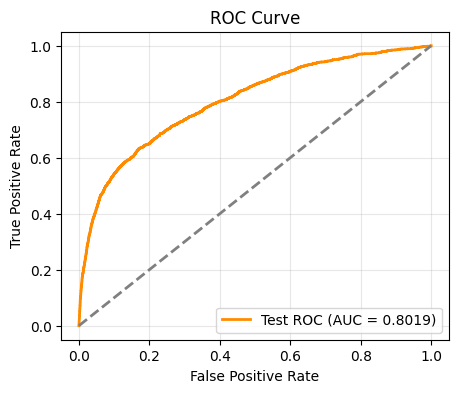

In [165]:
test_roc_auc = roc_auc_score(y_test, y_pred_proba_test)

print("ROC AUC Score:", test_roc_auc, '\n')

fpr_test, tpr_test, _  = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(5, 4))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, 
         label=f'Test ROC (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

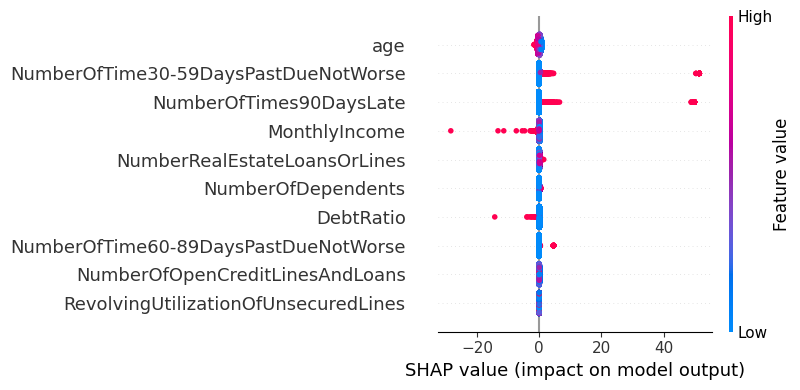

In [86]:
explainer = shap.LinearExplainer(baseline_model_pipeline[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 4))
plt.show()

---

## Tuned Logistic Regression

In [9]:
config_logreg = get_config()

In [10]:
config_logreg.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_logreg.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = True
)

config_logreg.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True
)

config_logreg.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = True
)

config_logreg.preprocessing.woe = WoEConfig(
    enabled = False
)

config_logreg.preprocessing.scaling = ScalingConfig(
    enabled = True
)

logreg_preprocessor_pipeline = create_preprocessing_pipeline(config_logreg)

In [87]:
# Just for visualization

logreg_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=logreg_preprocessor_pipeline.transform(X_train),
             columns=logreg_preprocessor_pipeline[:-2].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=logreg_preprocessor_pipeline.transform(X_test),
             columns=logreg_preprocessor_pipeline[:-2].get_feature_names_out())

X_train_processed.describe()

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,age^2,age^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,total_delinquencies,has_delinquency,weighted_delinquencies
count,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05,1.200000e+05
mean,-1.548983e-16,-1.288451e-16,-3.836931e-17,-1.965835e-17,1.681618e-17,-9.687066e-17,6.833053e-17,3.931670e-17,2.321106e-17,-1.989520e-17,7.579123e-18,-4.121148e-17,3.552714e-18,-4.808006e-17,4.002724e-17,2.794801e-17,1.226870e-16,-2.510584e-17,6.158037e-17,-5.933032e-17,6.300146e-17,-2.048732e-17,-6.631732e-18,9.900229e-17,-8.242296e-17,-1.421085e-18,-5.210647e-17,-9.710751e-18,-2.107943e-17,-2.273737e-17,2.984279e-17,1.089499e-17,-1.835569e-17,4.926430e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.126884e+00,-1.271676e+00,-9.121156e-01,-1.238587e+00,-6.803752e-01,-1.689370e+00,-1.007904e+00,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.047214e-01,-1.499830e-01,-2.708587e-01,-8.114171e-01,-5.093323e-01,-1.686828e-01,-4.978246e-01,-1.575551e+00,-1.200371e+00,-5.013326e-01,-2.588962e-01,-8.574814e-01,-5.488650e-01,-6.348305e-01,-4.277433e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
25%,-7.660726e-01,-8.535315e-01,-8.273641e-01,-5.753971e-01,-6.803752e-01,-6.867944e-01,-1.007904e+00,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.047214e-01,-1.499830e-01,-2.708587e-01,-8.114171e-01,-5.093323e-01,-1.686828e-01,-4.978246e-01,-7.959533e-01,-7.736421e-01,-4.143208e-01,-2.490756e-01,-6.338409e-01,-4.975484e-01,-6.348305e-01,-4.277433e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
50%,-1.762647e-02,-1.032617e-01,-4.730253e-01,-1.614044e-01,-6.803752e-01,-8.524901e-02,7.641983e-03,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,-6.889253e-01,-2.954345e-01,-1.055433e-01,-2.047214e-01,-1.499830e-01,-2.708587e-01,-8.114171e-01,-5.093323e-01,-1.686828e-01,-4.978246e-01,-1.527851e-01,-2.608875e-01,-2.717806e-01,-2.168147e-01,-2.849616e-01,-3.386722e-01,-3.100467e-01,-3.369442e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
75%,7.308196e-01,7.159715e-01,6.854645e-01,2.985527e-01,2.537891e-01,5.162964e-01,1.023188e+00,-3.692201e-01,-2.184852e-01,-2.159654e-01,-4.957646e-01,-1.635981e-01,-2.504546e-01,1.451536e+00,-2.954345e-01,-1.055433e-01,-2.047214e-01,-1.499830e-01,-2.708587e-01,1.232412e+00,-5.093323e-01,-1.686828e-01,-4.978246e-01,6.425304e-01,5.218955e-01,-3.388903e-02,-1.366139e-01,2.249389e-01,-2.445811e-03,6.643046e-01,2.986496e-01,-3.809332e-01,-5.040073e-01,-3.367521e-01
max,2.363793e+00,1.855001e+00,1.951794e+00,

In [12]:
logreg_model_pipeline = Pipeline(
    [
        ('preprocessing', logreg_preprocessor_pipeline),
        ('logreg', LogisticRegression(random_state=42,
                                      solver='saga',
                                      max_iter=5000,
                                      class_weight='balanced'))
    ]
)

In [13]:
param_grid_v1 = {
    'logreg__C': [2500, 5000, 7500],
    'logreg__l1_ratio': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
}

grid_search_v1 = GridSearchCV(
    estimator=logreg_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v1.best_params_)
print(f"Best cross-validated AUC: {grid_search_v1.best_score_:.4f}")

best_model = grid_search_v1.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'logreg__C': 2500, 'logreg__l1_ratio': 0.0}
Best cross-validated AUC: 0.8615
Test AUC: 0.8655


In [167]:
param_grid_v2 = {
    'logreg__C': [2250, 2500, 2750],
    'logreg__l1_ratio': [0.0, 0.01],
}

grid_search_v2 = GridSearchCV(
    estimator=logreg_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v2.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v2.best_params_)
print(f"Best cross-validated AUC: {grid_search_v2.best_score_:.4f}")

best_model = grid_search_v2.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'logreg__C': 2500, 'logreg__l1_ratio': 0.0}
Best cross-validated AUC: 0.8615
Test AUC: 0.8655


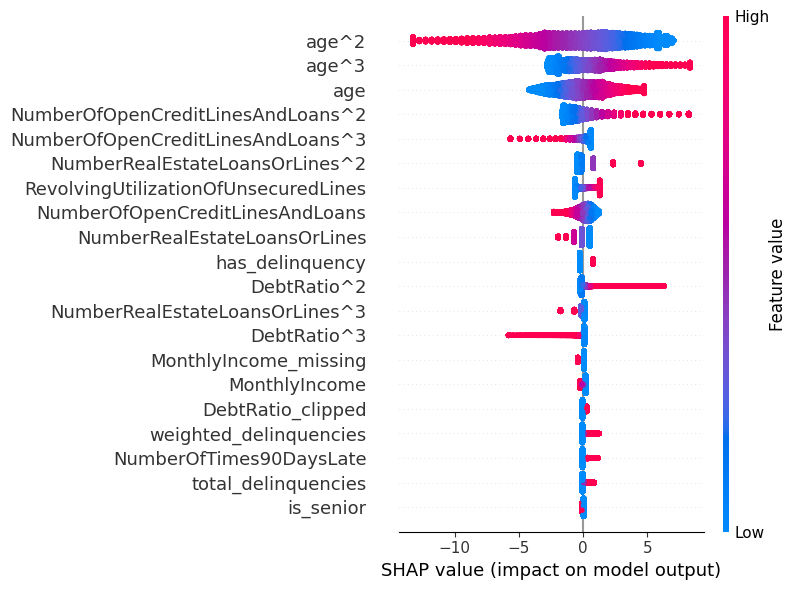

In [88]:
explainer = shap.LinearExplainer(best_model[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

In [147]:
selector = SelectFromModel(
    estimator=best_model[-1],
    prefit=True,
    threshold="0.27*mean",
)

selected_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_mask]

print(f"\nNumber of selected features: {len(selected_features)} / {X_train_processed.shape[1]}:\n")
print(', '.join(selected_features.tolist()))


Number of selected features: 16 / 34:

age, RevolvingUtilizationOfUnsecuredLines, NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines, NumberOfTimes90DaysLate, MonthlyIncome_missing, age^2, age^3, DebtRatio^2, DebtRatio^3, NumberOfOpenCreditLinesAndLoans^2, NumberOfOpenCreditLinesAndLoans^3, NumberRealEstateLoansOrLines^2, NumberRealEstateLoansOrLines^3, has_delinquency, weighted_delinquencies


In [152]:
final_logreg = best_model[-1].__class__(**best_model[-1].get_params())

final_logreg_pipeline = Pipeline([
    ('preprocessing', logreg_preprocessor_pipeline),
    ('feature_selection', selector),
    ('logreg', final_logreg)
])

final_logreg_pipeline.fit(X_train, y_train)

y_pred_test = final_logreg_pipeline.predict(X_test)
y_pred_proba_test = final_logreg_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.8640


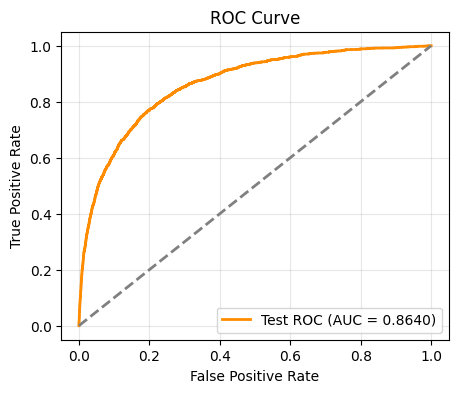

In [156]:
fpr_test, tpr_test, _  = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(5, 4))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, 
         label=f'Test ROC (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

---

## Logistic Regression with WoE features

In [18]:
config_woe = get_config()

In [168]:
config_woe.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_woe.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_woe.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = False
)

config_woe.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_woe.preprocessing.woe = WoEConfig(
    enabled = True
)

config_woe.preprocessing.scaling = ScalingConfig(
    enabled = False
)

In [ ]:
woe_preprocessor_pipeline = create_preprocessing_pipeline(config_woe)

woe_model_pipeline = Pipeline(
    [
        ('preprocessing', woe_preprocessor_pipeline),
        ('logreg', LogisticRegression(random_state=42))
    ]
)

In [ ]:
param_grid_v1 = {
    'logreg__C': np.logspace(-4, 4, 3),
    'logreg__l1_ratio': [0.0, 0.1, 0.35, 0.65, 0.9, 1.0],
    'logreg__class_weight': ['balanced'],
    'logreg__solver': ['saga'],
    'logreg__max_iter': [500],
}

grid_search = GridSearchCV(
    estimator=logreg_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validated AUC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

---

## **XGBoost Classifier**

In [169]:
config_xgb = get_config()

In [171]:
config_xgb.preprocessing.indicator_extraction = IndicatorExtractionConfig(
    enabled = True
)

config_xgb.preprocessing.outlier_clipping = OutlierClippingConfig(
    enabled = False
)

config_xgb.preprocessing.feature_creation = FeatureCreationConfig(
    enabled = True
    # add_age_polynomial = True
    # add_debt_ratio_polynomial = True
    # add_loans_polynomial = True
    # add_estate_polynomial = True
)

config_xgb.preprocessing.feature_transformation = FeatureTransformationConfig(
    enabled = False
)

config_xgb.preprocessing.woe = WoEConfig(
    enabled = False
)

config_xgb.preprocessing.scaling = ScalingConfig(
    enabled = False
)

xgb_preprocessor_pipeline = create_preprocessing_pipeline(config_xgb)

In [193]:
# Just for visualization

xgb_preprocessor_pipeline.fit(X_train)
 
X_train_processed = pd.DataFrame(data=xgb_preprocessor_pipeline.transform(X_train),
             columns=xgb_preprocessor_pipeline[:-2].get_feature_names_out())
X_test_processed  = pd.DataFrame(data=xgb_preprocessor_pipeline.transform(X_test),
             columns=xgb_preprocessor_pipeline[:-2].get_feature_names_out())

X_train_processed.describe()

,age,MonthlyIncome,RevolvingUtilizationOfUnsecuredLines,DebtRatio,NumberOfDependents,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome_missing,NumberOfDependents_missing,is_young,is_senior,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,age^2,age^3,DebtRatio^2,DebtRatio^3,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,total_delinquencies,has_delinquency,weighted_delinquencies
count,120000.000000,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,1.200000e+05,1.200000e+05,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,52.287842,5.339220e+03,6.128916,352.271245,0.737592,8.465692,1.018167,0.420075,0.239858,0.264942,0.197292,0.026067,0.059025,0.321858,0.080275,0.011017,0.040225,0.022000,0.068350,0.397008,0.205983,0.027667,0.198608,2952.207108,1.777819e+05,4.507678e+06,9.146004e+11,98.310792,1452.332792,2.320467,10.435517,0.924875,0.202567,1.694617
std,14.771274,1.329420e+04,253.361490,2093.709509,1.107299,5.161693,1.133055,4.182138,4.144569,4.158242,0.397956,0.159334,0.235672,0.467191,0.271720,0.104381,0.196487,0.146684,0.252347,0.489280,0.404420,0.164017,0.398954,1607.216335,1.425367e+05,5.267458e+08,1.672968e+14,130.520673,3855.114324,12.166159,488.169038,12.434022,0.401914,24.863757
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,1.556750e+03,0.029593,0.175330,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1681.000000,6.892100e+04,3.074072e-02,5.389781e-03,25.000000,125.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,52.000000,4.350000e+03,0.153318,0.366194,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2704.000000,1.406080e+05,1.340982e-01,4.910600e-02,64.000000,512.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,63.000000,7.400000e+03,0.557832,0.860833,1.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3969.000000,2.500470e+05,7.410338e-01,6.379064e-01,121.000000,1331.000000,4.000000,8.000000,0.000000,0.000000,0.000000
max,109.000000,3.008750e+06,50708.000000,329664.000000,20.000000,58.000000,54.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11881.000000,1.295029e+06,1.086784e+11,3.582734e+16,3364.000000,195112.000000,2916.000000,157464.000000,294.000000,1.000000,588.000000


In [174]:
xgb_model_pipeline = Pipeline(
    [
        ('preprocessing', xgb_preprocessor_pipeline),
        ('xgb', XGBClassifier(
            random_state=42,
            scale_pos_weight=np.sum(y_train == 0) / np.sum(y_train == 1),
            eval_metric='auc',
            objective='binary:logistic',
            n_jobs=-1,
        ))
    ]
)

In [182]:
param_grid_v1 = {
    'xgb__n_estimators': [100, 200, 400],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.7, 1.0],
    'xgb__colsample_bytree': [0.7, 1.0],
}

grid_search_v1 = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_v1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2,
)

grid_search_v1.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v1.best_params_)
print(f"Best cross-validated AUC: {grid_search_v1.best_score_:.4f}")

best_model = grid_search_v1.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 400, 'xgb__subsample': 0.7}
Best cross-validated AUC: 0.8652
Test AUC: 0.8698


In [191]:
param_grid_v2 = {
    'xgb__n_estimators': [300, 400, 600],
    'xgb__max_depth': [2, 3, 4],
    'xgb__learning_rate': [0.03, 0.05, 0.07],
    'xgb__subsample': [0.6, 0.7, 0.8],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8],
}

grid_search_v2 = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_v2,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v2.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v2.best_params_)
print(f"Best cross-validated AUC: {grid_search_v2.best_score_:.4f}")

best_model = grid_search_v2.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.03, 'xgb__max_depth': 4, 'xgb__n_estimators': 300, 'xgb__subsample': 0.7}
Best cross-validated AUC: 0.8654
Test AUC: 0.8700


In [189]:
param_grid_v3 = {
    'xgb__n_estimators': [200, 300, 400, 500],
    'xgb__max_depth': [2, 3, 4, 5],
    'xgb__learning_rate': [0.02, 0.03, 0.04],
    'xgb__subsample': [0.75, 0.8, 0.85],
    'xgb__colsample_bytree': [0.75, 0.8, 0.85],
}

grid_search_v3 = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=param_grid_v3,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid_search_v3.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search_v3.best_params_)
print(f"Best cross-validated AUC: {grid_search_v3.best_score_:.4f}")

best_model = grid_search_v3.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"Test AUC: {test_auc:.4f}")

Best parameters found:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.03, 'xgb__max_depth': 4, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
Best cross-validated AUC: 0.8654
Test AUC: 0.8697


In [192]:
explainer = shap.TreeExplainer(best_model[-1], X_train_processed)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, plot_size=(8, 6))
plt.show()

 98%|===================| 29289/30000 [00:33<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was -2.188636, while the model output was 0.783623. If this difference is acceptable you can set check_additivity=False to disable this check.